# Analisis de Resultados: Algoritmos Geneticos (AG) vs Hibrido (AG-CRO)

Comparacion entre el Algoritmo Genetico puro y el Algoritmo Hibrido que combina AG con Optimizacion de Reacciones Quimicas (CRO).

In [146]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs('analisis', exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

data_dir = '../'

ag_files = [f'{data_dir}resultadosAG_{i}.csv' for i in range(1, 6)]
h_files = [f'{data_dir}resultadosH_{i}.csv' for i in range(1, 6)]

In [147]:
ag_data = {f'AG_{i}': pd.read_csv(f) for i, f in enumerate(ag_files, 1)}
h_data = {f'H_{i}': pd.read_csv(f) for i, f in enumerate(h_files, 1)}

ag_avg = pd.concat([df['promedio'] for df in ag_data.values()], axis=1).mean(axis=1)
h_avg = pd.concat([df['promedio'] for df in h_data.values()], axis=1).mean(axis=1)
iteraciones = ag_data['AG_1']['iteracion']

ag_mejor_avg = pd.concat([df['mejor'] for df in ag_data.values()], axis=1).mean(axis=1)
h_mejor_avg = pd.concat([df['mejor'] for df in h_data.values()], axis=1).mean(axis=1)

ag_mejor_final = [df['mejor'].iloc[-1] for df in ag_data.values()]
h_mejor_final = [df['mejor'].iloc[-1] for df in h_data.values()]
ag_tiempo_total = [df['tiempo'].sum() for df in ag_data.values()]
h_tiempo_total = [df['tiempo'].sum() for df in h_data.values()]

colors_ag = ['#27ae60', '#2ecc71', '#229954', '#1e8449', '#196f3d']
colors_h = ['#e74c3c', '#c0392b', '#a93226', '#922b21', '#7b241c']

print(f'AG: {len(ag_data)} archivos, {len(ag_data["AG_1"])} iteraciones c/u')
print(f'H:  {len(h_data)} archivos, {len(h_data["H_1"])} iteraciones c/u')

AG: 5 archivos, 2000 iteraciones c/u
H:  5 archivos, 2000 iteraciones c/u


---
## 1. Analisis Individual por Algoritmo

### 1.1 Promedio por Iteracion

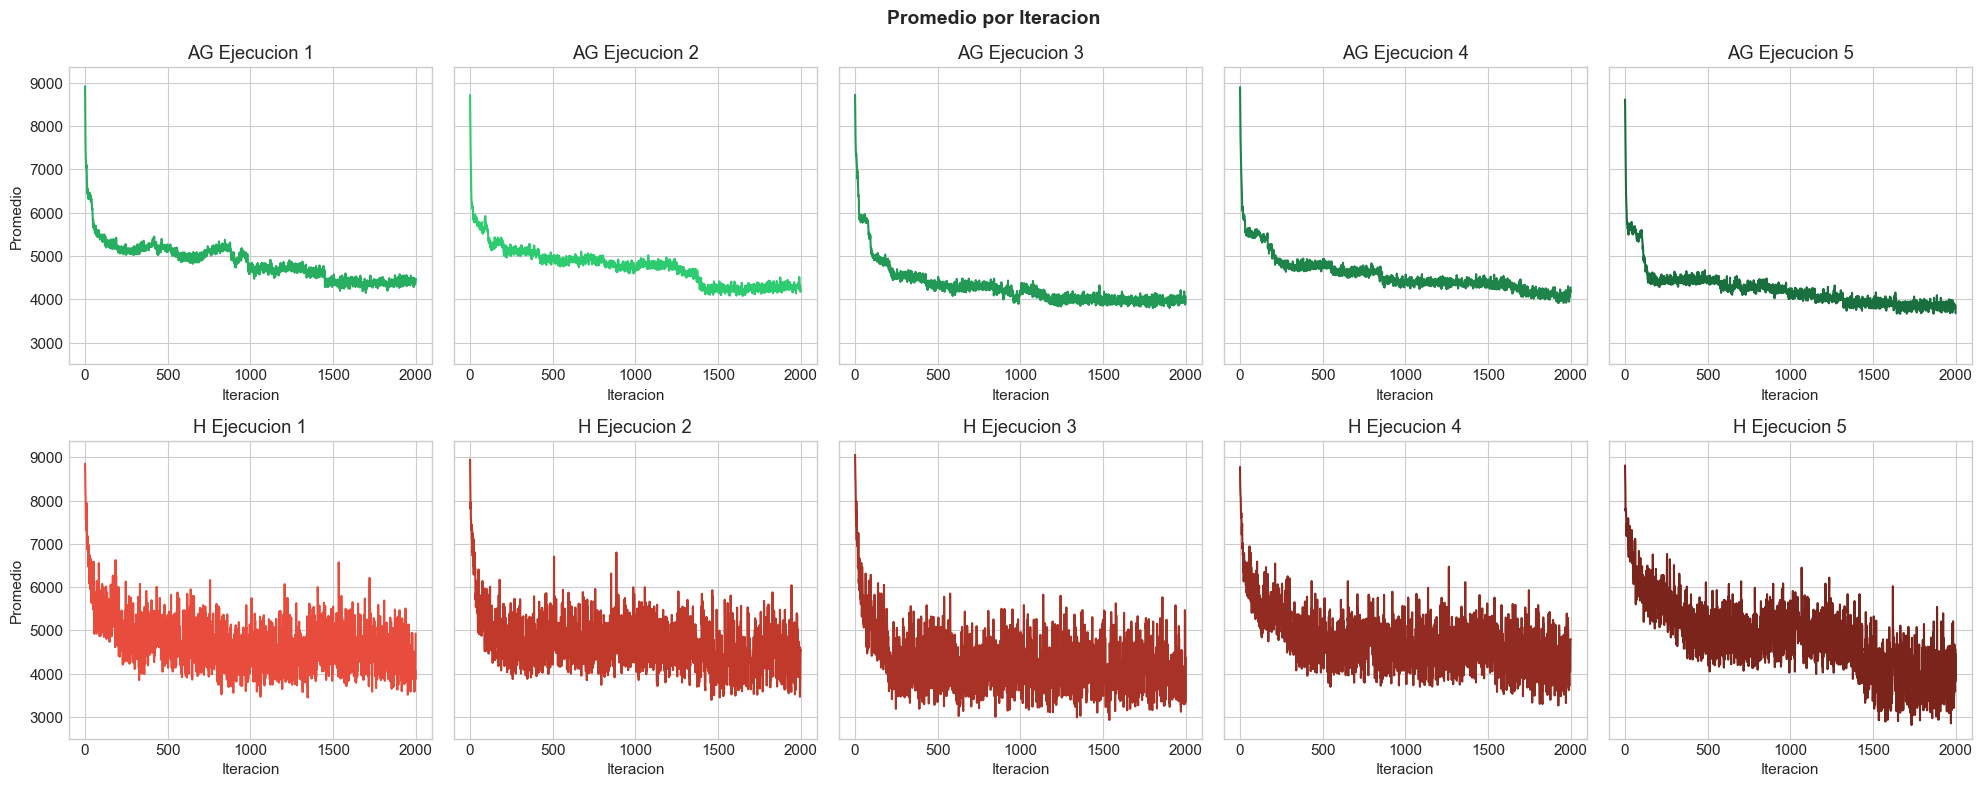

In [148]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True)

for i in range(5):
    axes[0, i].plot(ag_data[f'AG_{i+1}']['iteracion'], ag_data[f'AG_{i+1}']['promedio'], color=colors_ag[i])
    axes[0, i].set_title(f'AG Ejecucion {i+1}')
    axes[0, i].set_xlabel('Iteracion')
    if i == 0:
        axes[0, i].set_ylabel('Promedio')

    axes[1, i].plot(h_data[f'H_{i+1}']['iteracion'], h_data[f'H_{i+1}']['promedio'], color=colors_h[i])
    axes[1, i].set_title(f'H Ejecucion {i+1}')
    axes[1, i].set_xlabel('Iteracion')
    if i == 0:
        axes[1, i].set_ylabel('Promedio')

plt.suptitle('Promedio por Iteracion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.2 Mejor Valor por Iteracion

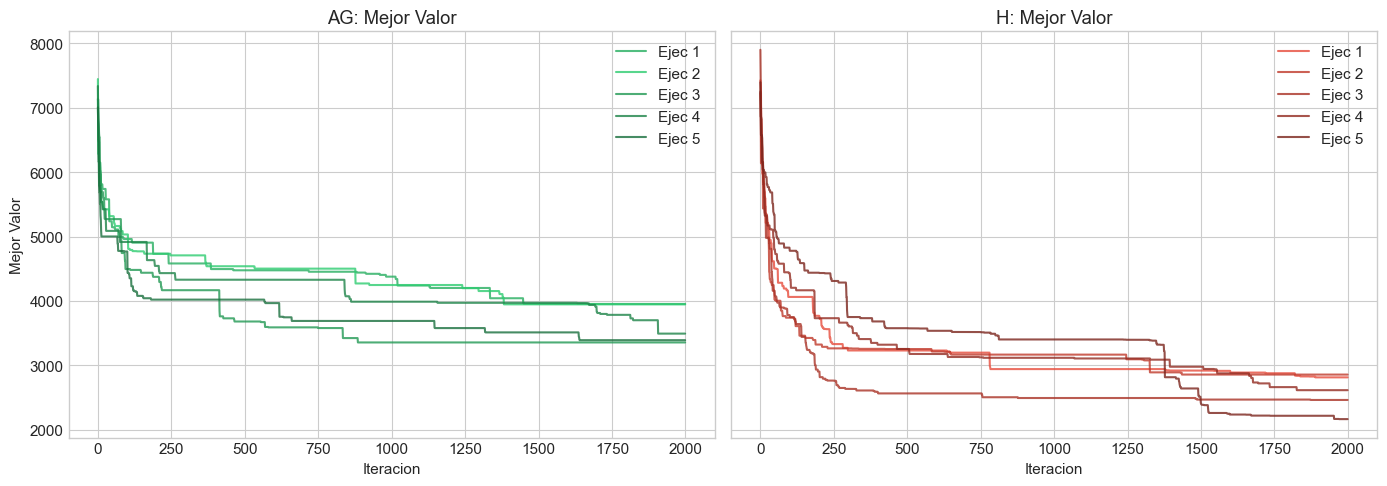

In [149]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i in range(5):
    axes[0].plot(ag_data[f'AG_{i+1}']['iteracion'], ag_data[f'AG_{i+1}']['mejor'], color=colors_ag[i], alpha=0.8)
axes[0].set_title('AG: Mejor Valor')
axes[0].set_xlabel('Iteracion')
axes[0].set_ylabel('Mejor Valor')
axes[0].legend(['Ejec 1', 'Ejec 2', 'Ejec 3', 'Ejec 4', 'Ejec 5'])

for i in range(5):
    axes[1].plot(h_data[f'H_{i+1}']['iteracion'], h_data[f'H_{i+1}']['mejor'], color=colors_h[i], alpha=0.8)
axes[1].set_title('H: Mejor Valor')
axes[1].set_xlabel('Iteracion')
axes[1].legend(['Ejec 1', 'Ejec 2', 'Ejec 3', 'Ejec 4', 'Ejec 5'])

plt.tight_layout()
plt.show()

### 1.3 Tiempo por Iteracion

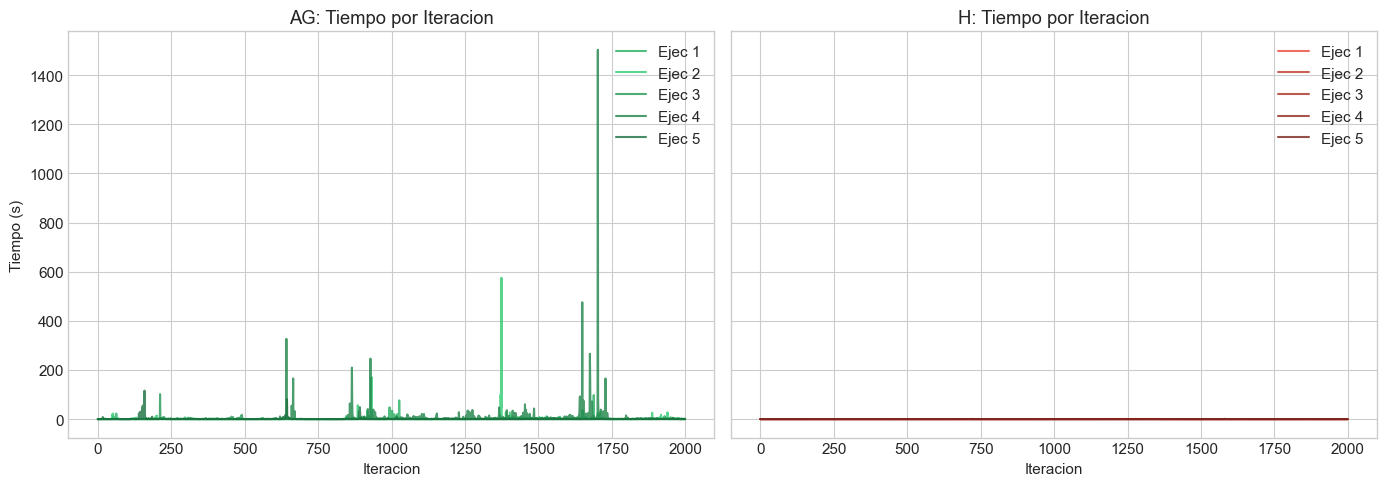

In [150]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i in range(5):
    axes[0].plot(ag_data[f'AG_{i+1}']['iteracion'], ag_data[f'AG_{i+1}']['tiempo'], color=colors_ag[i], alpha=0.8)
axes[0].set_title('AG: Tiempo por Iteracion')
axes[0].set_xlabel('Iteracion')
axes[0].set_ylabel('Tiempo (s)')
axes[0].legend(['Ejec 1', 'Ejec 2', 'Ejec 3', 'Ejec 4', 'Ejec 5'])

for i in range(5):
    axes[1].plot(h_data[f'H_{i+1}']['iteracion'], h_data[f'H_{i+1}']['tiempo'], color=colors_h[i], alpha=0.8)
axes[1].set_title('H: Tiempo por Iteracion')
axes[1].set_xlabel('Iteracion')
axes[1].legend(['Ejec 1', 'Ejec 2', 'Ejec 3', 'Ejec 4', 'Ejec 5'])

plt.tight_layout()
plt.show()

### 1.4 Comparacion por Archivo: Tiempo, Promedio y Mejor

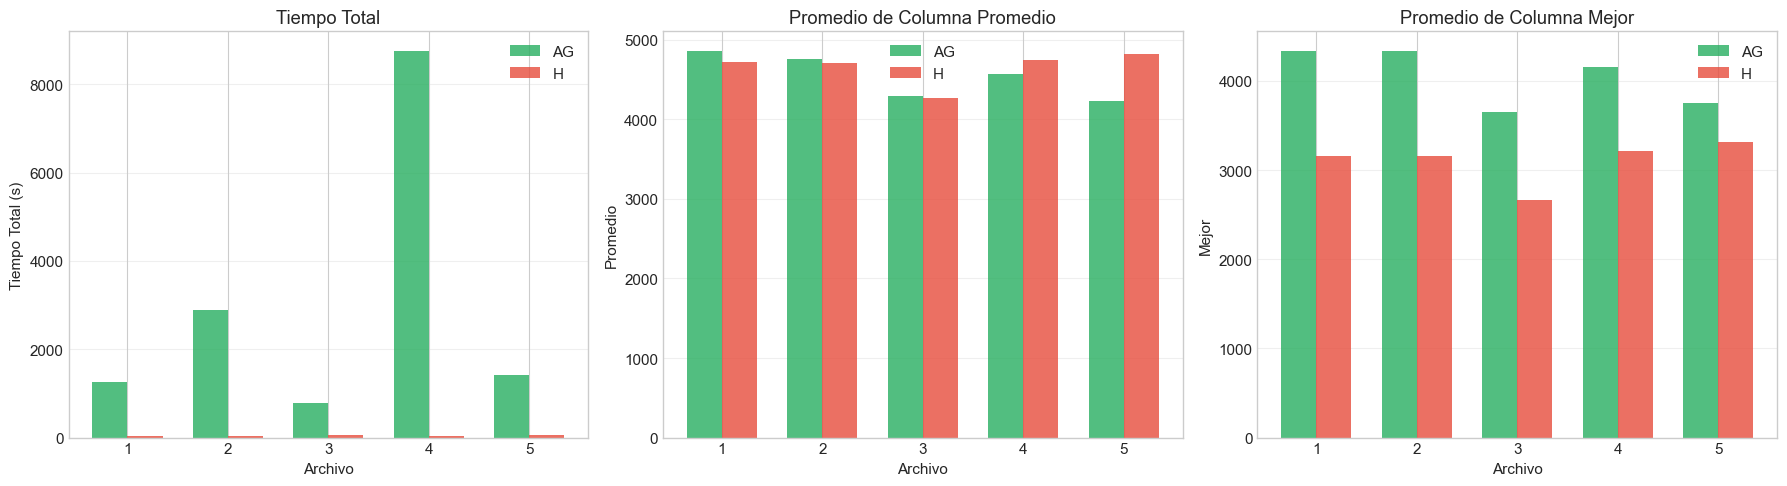

In [151]:
ag_tiempo_total = [df['tiempo'].sum() for df in ag_data.values()]
h_tiempo_total = [df['tiempo'].sum() for df in h_data.values()]

ag_promedio_medio = [df['promedio'].mean() for df in ag_data.values()]
h_promedio_medio = [df['promedio'].mean() for df in h_data.values()]

ag_mejor_medio = [df['mejor'].mean() for df in ag_data.values()]
h_mejor_medio = [df['mejor'].mean() for df in h_data.values()]

x = np.arange(1, 6)
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(x - width/2, ag_tiempo_total, width, label='AG', color='#27ae60', alpha=0.8)
axes[0].bar(x + width/2, h_tiempo_total, width, label='H', color='#e74c3c', alpha=0.8)
axes[0].set_xlabel('Archivo')
axes[0].set_ylabel('Tiempo Total (s)')
axes[0].set_title('Tiempo Total')
axes[0].set_xticks(x)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(x - width/2, ag_promedio_medio, width, label='AG', color='#27ae60', alpha=0.8)
axes[1].bar(x + width/2, h_promedio_medio, width, label='H', color='#e74c3c', alpha=0.8)
axes[1].set_xlabel('Archivo')
axes[1].set_ylabel('Promedio')
axes[1].set_title('Promedio de Columna Promedio')
axes[1].set_xticks(x)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

axes[2].bar(x - width/2, ag_mejor_medio, width, label='AG', color='#27ae60', alpha=0.8)
axes[2].bar(x + width/2, h_mejor_medio, width, label='H', color='#e74c3c', alpha=0.8)
axes[2].set_xlabel('Archivo')
axes[2].set_ylabel('Mejor')
axes[2].set_title('Promedio de Columna Mejor')
axes[2].set_xticks(x)
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---
## 2. Comparacion AG vs H

### 2.1 Convergencia: Promedio por Iteracion (Escala sincronizada)

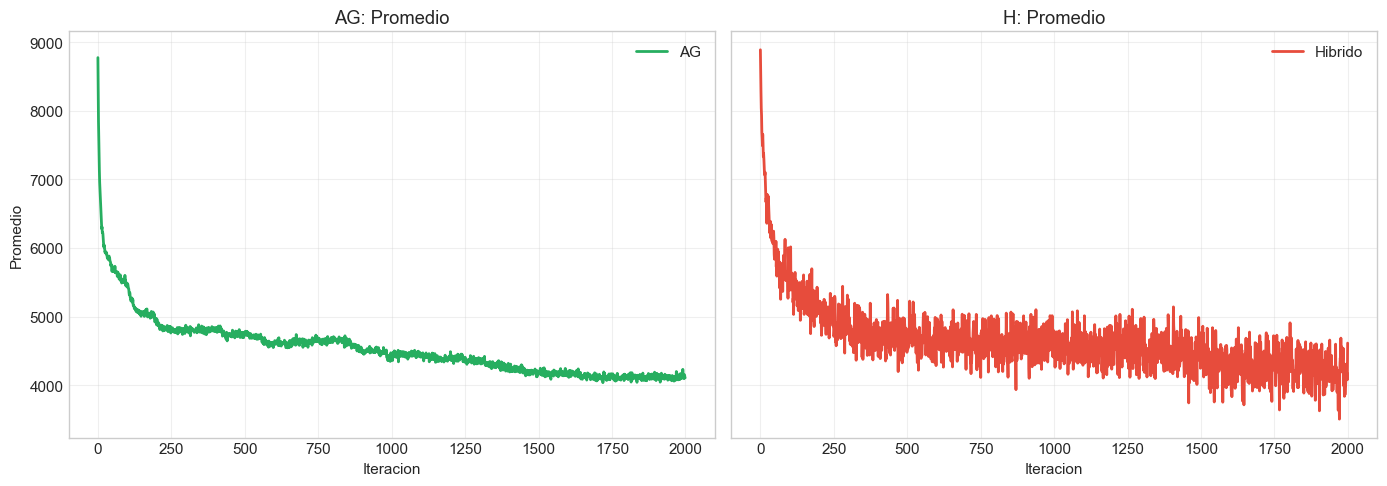

In [152]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].plot(iteraciones, ag_avg, label='AG', color='#27ae60', linewidth=2)
axes[0].set_xlabel('Iteracion')
axes[0].set_ylabel('Promedio')
axes[0].set_title('AG: Promedio')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(iteraciones, h_avg, label='Hibrido', color='#e74c3c', linewidth=2)
axes[1].set_xlabel('Iteracion')
axes[1].set_title('H: Promedio')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.2 Mejor Valor Encontrado

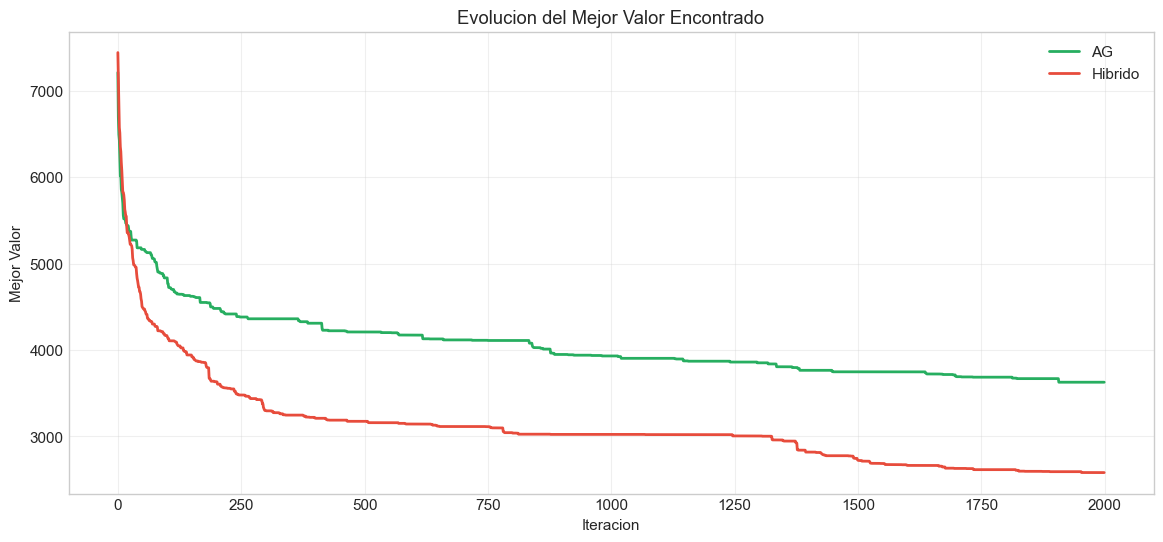

In [153]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(iteraciones, ag_mejor_avg, label='AG', color='#27ae60', linewidth=2)
ax.plot(iteraciones, h_mejor_avg, label='Hibrido', color='#e74c3c', linewidth=2)
ax.set_xlabel('Iteracion')
ax.set_ylabel('Mejor Valor')
ax.set_title('Evolucion del Mejor Valor Encontrado')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

### 2.3 Tiempo Promedio por Iteracion (Escala sincronizada)

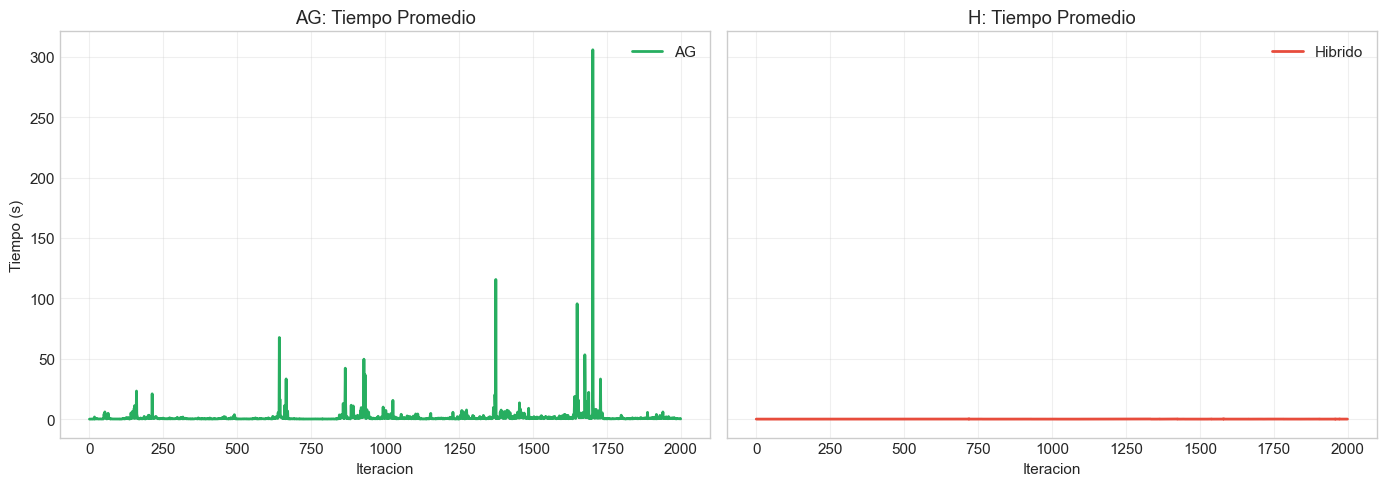

In [154]:
ag_tiempo_avg = pd.concat([df['tiempo'] for df in ag_data.values()], axis=1).mean(axis=1)
h_tiempo_avg = pd.concat([df['tiempo'] for df in h_data.values()], axis=1).mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].plot(iteraciones, ag_tiempo_avg, label='AG', color='#27ae60', linewidth=2)
axes[0].set_xlabel('Iteracion')
axes[0].set_ylabel('Tiempo (s)')
axes[0].set_title('AG: Tiempo Promedio')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(iteraciones, h_tiempo_avg, label='Hibrido', color='#e74c3c', linewidth=2)
axes[1].set_xlabel('Iteracion')
axes[1].set_title('H: Tiempo Promedio')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3. Resumen Estadistico

In [155]:
resumen = pd.DataFrame({
    'Metrica': [
        'Mejor Solucion Final (Media)',
        'Mejor Solucion Final (Std)',
        'Mejor Solucion Final (Min)',
        'Mejor Solucion Final (Max)',
        'Tiempo Total Medio (s)',
        'Tiempo por Iteracion (ms)',
        'Promedio Inicial',
        'Promedio Final',
        'Mejora Total (%)'
    ],
    'AG': [
        f"{np.mean(ag_mejor_final):.2f}",
        f"{np.std(ag_mejor_final):.2f}",
        f"{min(ag_mejor_final):.2f}",
        f"{max(ag_mejor_final):.2f}",
        f"{np.mean(ag_tiempo_total):.2f}",
        f"{np.mean([df['tiempo'].mean()*1000 for df in ag_data.values()]):.3f}",
        f"{ag_avg.iloc[0]:.2f}",
        f"{ag_avg.iloc[-1]:.2f}",
        f"{(1 - ag_avg.iloc[-1]/ag_avg.iloc[0])*100:.1f}"
    ],
    'H': [
        f"{np.mean(h_mejor_final):.2f}",
        f"{np.std(h_mejor_final):.2f}",
        f"{min(h_mejor_final):.2f}",
        f"{max(h_mejor_final):.2f}",
        f"{np.mean(h_tiempo_total):.2f}",
        f"{np.mean([df['tiempo'].mean()*1000 for df in h_data.values()]):.3f}",
        f"{h_avg.iloc[0]:.2f}",
        f"{h_avg.iloc[-1]:.2f}",
        f"{(1 - h_avg.iloc[-1]/h_avg.iloc[0])*100:.1f}"
    ]
})

print(resumen.to_string(index=False))
resumen.to_csv('analisis/resumen_comparativo.csv', index=False)

                     Metrica       AG       H
Mejor Solucion Final (Media)  3627.46 2581.87
  Mejor Solucion Final (Std)   266.84  252.29
  Mejor Solucion Final (Min)  3355.22 2164.42
  Mejor Solucion Final (Max)  3953.18 2856.02
      Tiempo Total Medio (s)  3019.56   45.46
   Tiempo por Iteracion (ms) 1509.782  22.729
            Promedio Inicial  8775.40 8889.50
              Promedio Final  4106.97 4613.41
            Mejora Total (%)     53.2    48.1


---
## 4. Conclusiones

In [156]:
mejora_calidad = (np.mean(ag_mejor_final) - np.mean(h_mejor_final)) / np.mean(ag_mejor_final) * 100
mejora_tiempo = (np.mean(ag_tiempo_total) - np.mean(h_tiempo_total)) / np.mean(ag_tiempo_total) * 100

print("=== CONCLUSIONES ===")
print(f"\n1. CALIDAD DE SOLUCION:")
print(f"   AG: {np.mean(ag_mejor_final):.2f} | H: {np.mean(h_mejor_final):.2f}")
print(f"   El Hibrido es {mejora_calidad:.1f}% mejor que AG")

print(f"\n2. VELOCIDAD:")
print(f"   AG: {np.mean(ag_tiempo_total):.2f}s | H: {np.mean(h_tiempo_total):.2f}s")
print(f"   El Hibrido es {mejora_tiempo:.1f}% mas rapido")


=== CONCLUSIONES ===

1. CALIDAD DE SOLUCION:
   AG: 3627.46 | H: 2581.87
   El Hibrido es 28.8% mejor que AG

2. VELOCIDAD:
   AG: 3019.56s | H: 45.46s
   El Hibrido es 98.5% mas rapido
